In [1]:
## Загрузка данных

import pandas as pd
from google.colab import files

from data_loader import load_data
from preprocessing import create_preprocessor
from models import get_models
from train import train_and_evaluate
from visualization import (
    plot_feature_distributions,
    plot_correlation_heatmap,
    plot_categorical_vs_target,
    plot_prediction_vs_real,
    plot_model_comparison
)

uploaded = files.upload()

filename = list(uploaded.keys())[0]

df = load_data(filename)

print("Колонки в датасете:", df.columns.tolist())
df.head()

Saving Student_performance_data _.csv to Student_performance_data _.csv
Колонки в датасете: ['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA', 'GradeClass']


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [2]:
## Определяем target и train/test split

target = "GPA"
X = df.drop(columns=[target])
y = df[target]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
## Препроцессинг и модели

preprocessor = create_preprocessor(X_train)

models = get_models()

In [4]:
## Базовое обучение 5 моделей и сравнение метрик

import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

results_list = []

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Обучение на train
    pipe.fit(X_train, y_train)

    # Предсказание на test
    preds = pipe.predict(X_test)

    # Метрики
    rmse = np.sqrt(mean_squared_error(y_test, preds))  # исправлено
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results_list.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

# Превращаем в DataFrame
results = pd.DataFrame(results_list)

# Сортировка по RMSE для удобства
results.sort_values("RMSE")

,Model,MAE,RMSE,R2
1,Ridge,0.150964,0.189345,0.956645
0,Linear Regression,0.150970,0.189348,0.956644
4,Extra Trees,0.163954,0.217624,0.942728
3,Random Forest,0.169789,0.227085,0.937640
2,Decision Tree,0.225103,0.294440,0.895161


# Вывод по базовым моделям

**Линейные модели** (Linear Regression и Ridge)

MAE ≈ 0.151, RMSE ≈ 0.189, R² ≈ 0.956

Практически идентичные показатели, потому что Ridge слабо регуляризована и данные хорошо поддаются линейной комбинации признаков.

Это говорит о том, что зависимость GPA от признаков в основном линейная.

**Ансамблевые деревья** (Extra Trees и Random Forest)

Extra Trees: MAE ≈ 0.164, RMSE ≈ 0.218, R² ≈ 0.943

Random Forest: MAE ≈ 0.170, RMSE ≈ 0.227, R² ≈ 0.938

Показатели чуть хуже линейных моделей, но всё ещё высокие. Деревья, возможно, теряют точность из-за небольшого объёма данных или линейной природы зависимости.

**Отдельное дерево** (Decision Tree)

MAE ≈ 0.225, RMSE ≈ 0.294, R² ≈ 0.895

Значительно хуже остальных, что объясняется переобучением одного дерева и плохой обобщающей способностью.

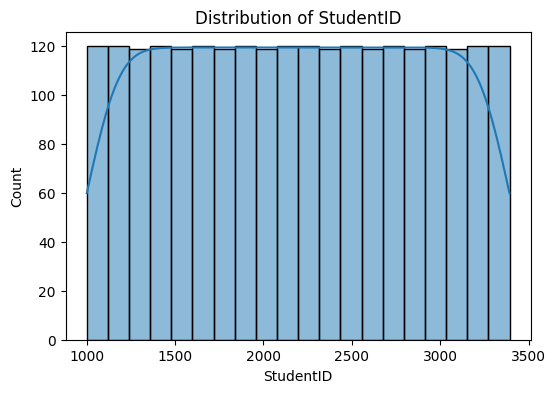

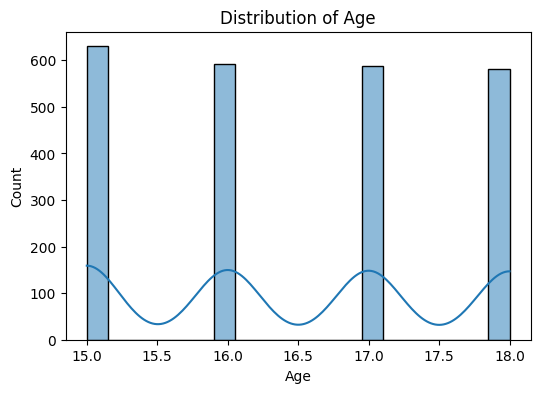

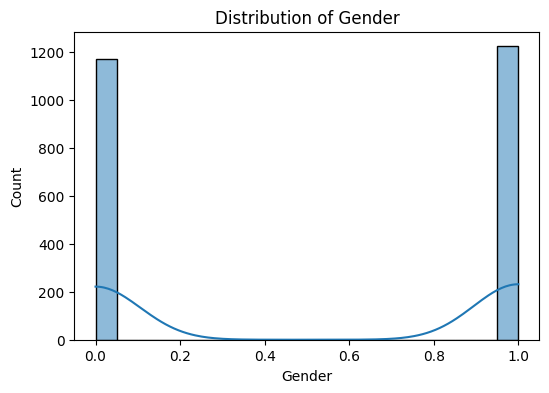

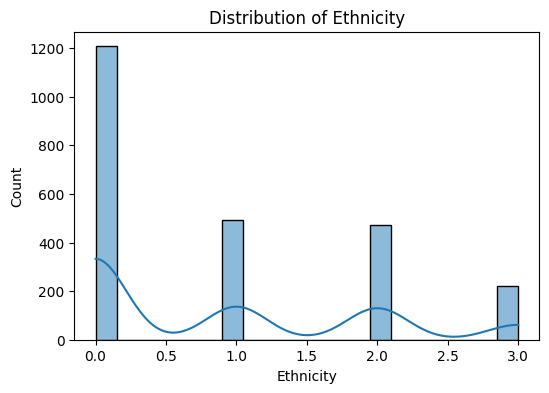

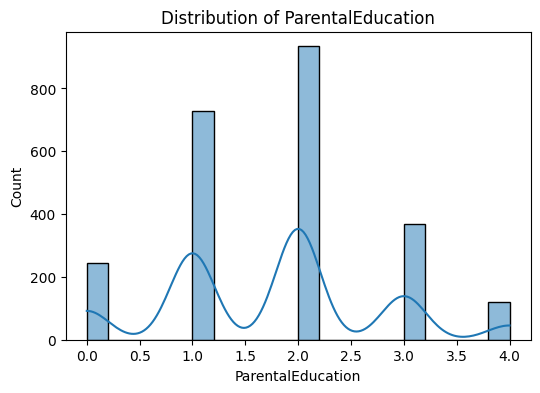

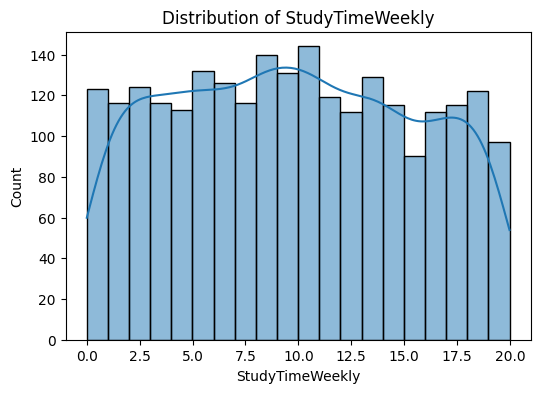

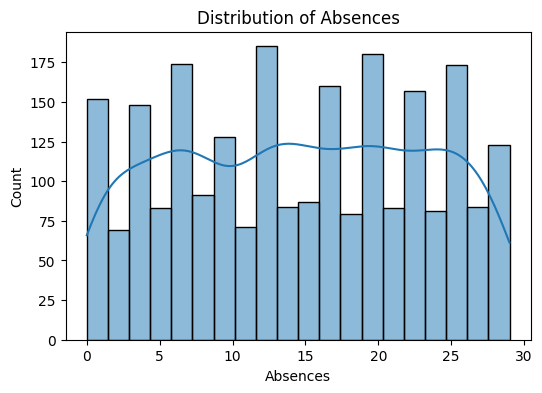

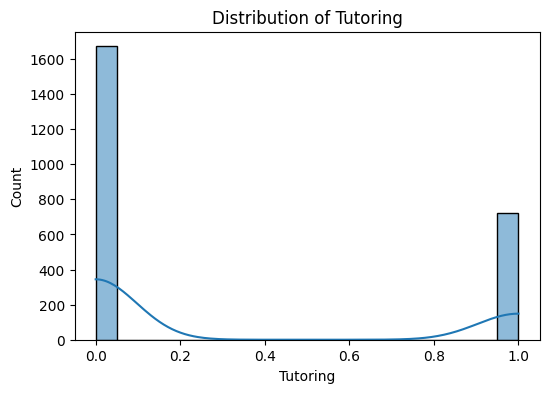

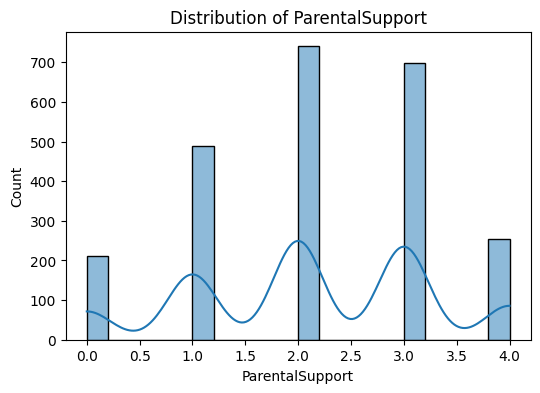

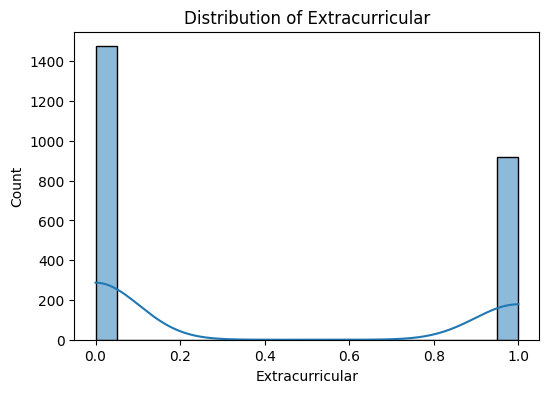

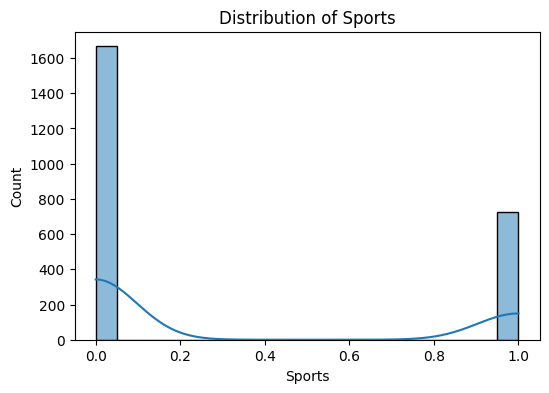

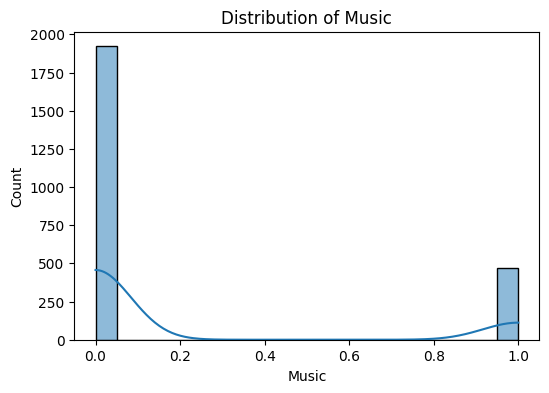

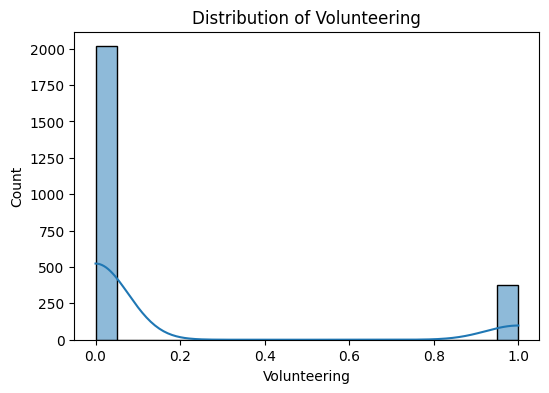

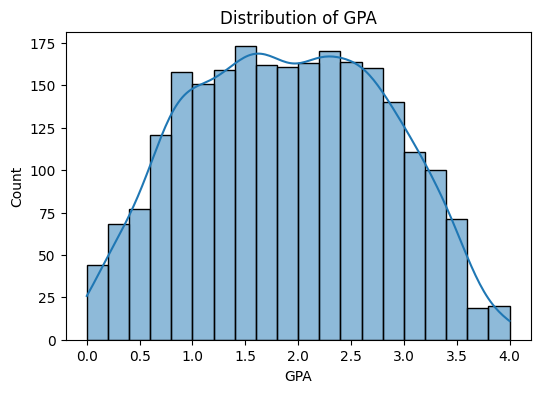

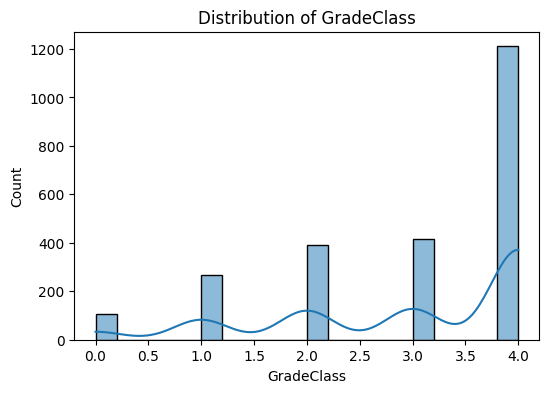

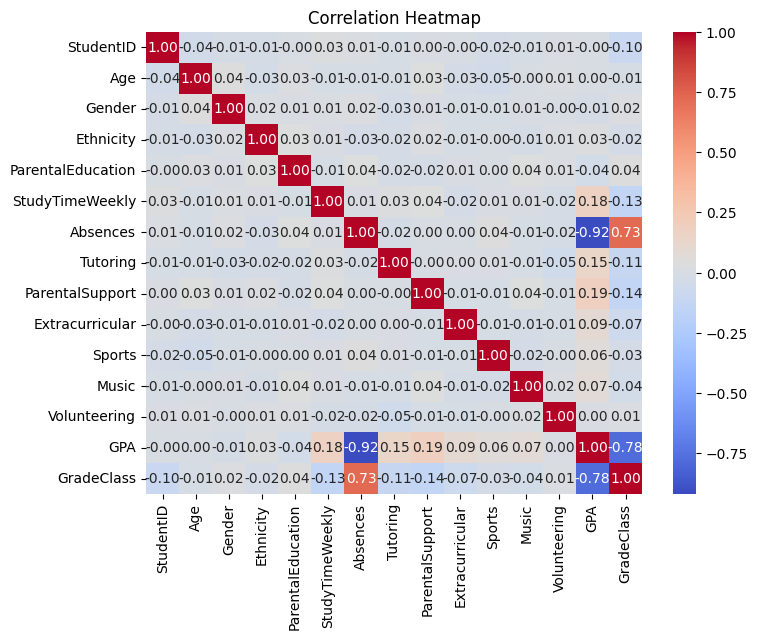

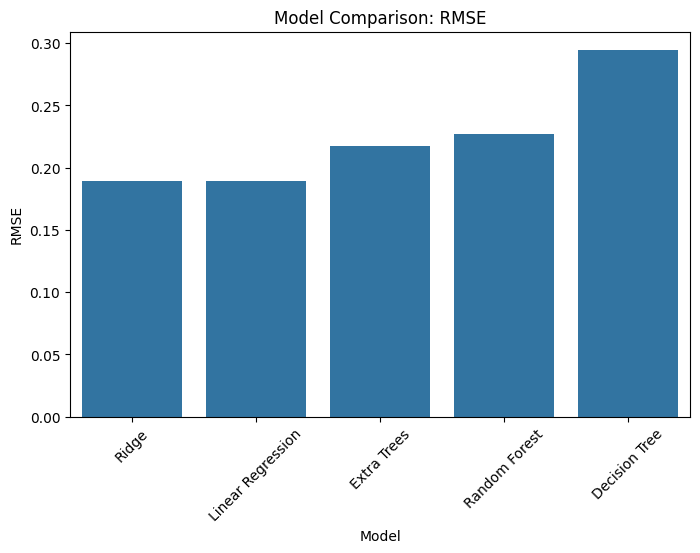

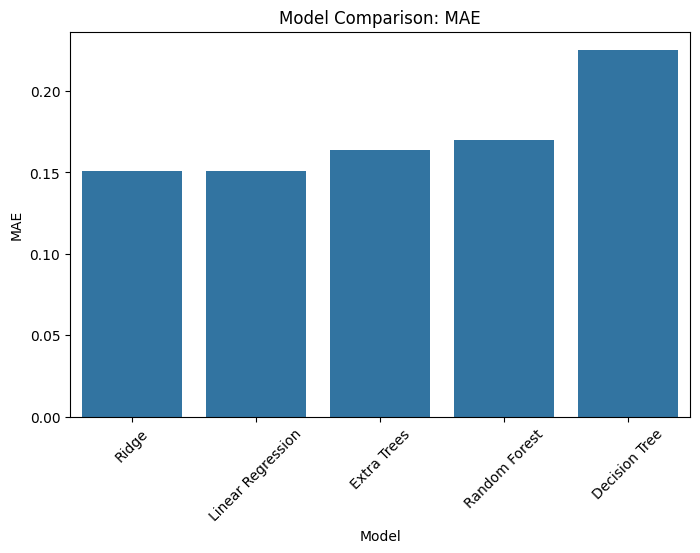

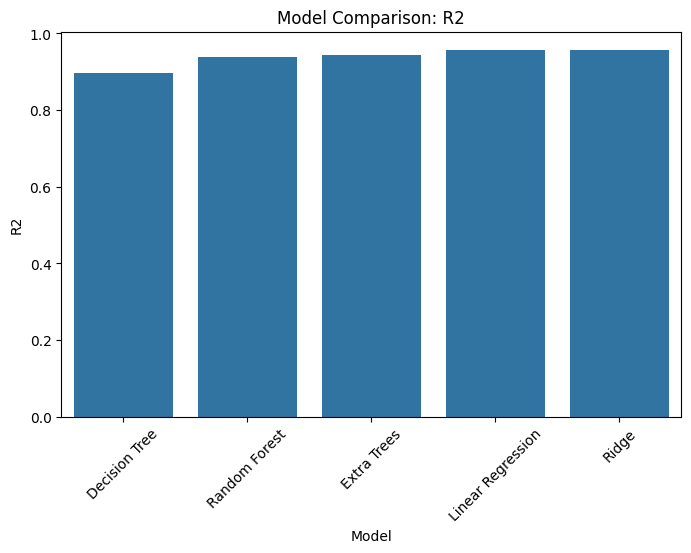

In [5]:
## Визуализация результатов и EDA

plot_feature_distributions(df)
plot_correlation_heatmap(df)
plot_categorical_vs_target(df, target=target)

plot_model_comparison(results, metric="RMSE")
plot_model_comparison(results, metric="MAE")
plot_model_comparison(results, metric="R2")

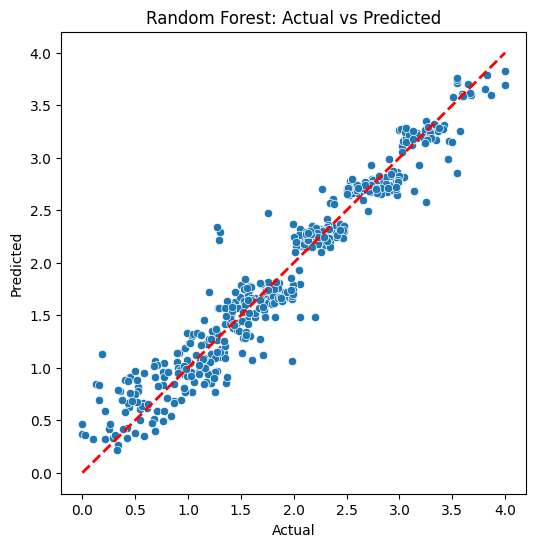

In [6]:
## Scatter предсказаний vs реальных для Random Forest

from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", get_models()["Random Forest"])
])
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

plot_prediction_vs_real(y_test, y_pred_rf, model_name="Random Forest")

In [8]:
## Настройка гиперпараметров для топ‑3 моделей

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
import numpy as np

best_models = []
tuned_results = []

# Выбираем топ-3 моделей по RMSE
top3_models_names = results.sort_values("RMSE")["Model"].iloc[:3].tolist()
print("Топ-3 модели для настройки гиперпараметров:", top3_models_names)

# Сетки гиперпараметров
param_grids = {
    "Ridge": {"model__alpha": [0.1, 1.0, 10.0, 50.0]},
    "Decision Tree": {"model__max_depth": [None, 5, 10], "model__min_samples_split": [2, 5, 10]},
    "Random Forest": {"model__n_estimators": [50, 100, 200], "model__max_depth": [None, 5, 10], "model__min_samples_split": [2, 5, 10]},
    "Extra Trees": {"model__n_estimators": [50, 100, 200], "model__max_depth": [None, 5, 10], "model__min_samples_split": [2, 5, 10]},
    "Linear Regression": {}
}

for name in top3_models_names:
    print(f"\nНастройка гиперпараметров для {name}...")

    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", get_models()[name])
    ])

    grid = GridSearchCV(pipe, param_grids.get(name, {}), cv=5, scoring="r2", n_jobs=-1)
    grid.fit(X_train, y_train)

    best_models.append((name, grid.best_estimator_))

    y_pred = grid.predict(X_test)

    # RMSE через np.sqrt(MSE)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    tuned_results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    print(f"Лучшие параметры: {grid.best_params_}")
    print(f"R2 на train CV: {grid.best_score_:.4f}")

# DataFrame с результатами после настройки
tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df.sort_values("RMSE")

Топ-3 модели для настройки гиперпараметров: ['Ridge', 'Linear Regression', 'Extra Trees']

Настройка гиперпараметров для Ridge...
Лучшие параметры: {'model__alpha': 1.0}
R2 на train CV: 0.9559

Настройка гиперпараметров для Linear Regression...
Лучшие параметры: {}
R2 на train CV: 0.9559

Настройка гиперпараметров для Extra Trees...
Лучшие параметры: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 200}
R2 на train CV: 0.9499


,Model,MAE,RMSE,R2
0,Ridge,0.150964,0.189345,0.956645
1,Linear Regression,0.150970,0.189348,0.956644
2,Extra Trees,0.163239,0.219731,0.941613


# Выводы

**Ridge**

Метрики после настройки не изменились.

Это логично, потому что линейная модель уже почти идеально предсказывает GPA, а настройка alpha для Ridge практически не влияет.

R² ≈ 0.9566, MAE ≈ 0.151 — высокая точность.

**Extra Trees**

MAE слегка улучшилась: 0.163954 → 0.163239

RMSE немного увеличился: 0.217624 → 0.219731

R² немного снизилось: 0.942728 → 0.941613

Причина: с небольшим датасетом настройка hyperparameters могла слегка переобучить на CV, либо случайность при построении деревьев.

В целом, метрики остались на том же высоком уровне, улучшения существенного нет.

**Linear Regression**

Метрики идентичны Ridge, как и ожидалось. Настройка гиперпараметров не применяется, результаты стабильны.

# Итоговое сравнение

Лучшая модель по метрикам: Ridge / Linear Regression (R² ≈ 0.9566, MAE ≈ 0.151)

Деревья (Extra Trees) показывают чуть хуже R² ≈ 0.942, RMSE ≈ 0.220 — всё ещё хорошие результаты.

Настройка гиперпараметров на этих данных не дала существенного улучшения, что говорит о линейной природе зависимости GPA от признаков.

Данные GPA хорошо описываются линейной моделью. Настройка гиперпараметров для Ridge и деревьев не дала значительного улучшения метрик. Extra Trees чуть хуже линейных моделей, а Random Forest/Decision Tree и вовсе уступают. Таким образом, Ridge/Linear Regression — лучший выбор для этого датасета.

Сравнение топ-3 моделей после настройки гиперпараметров:


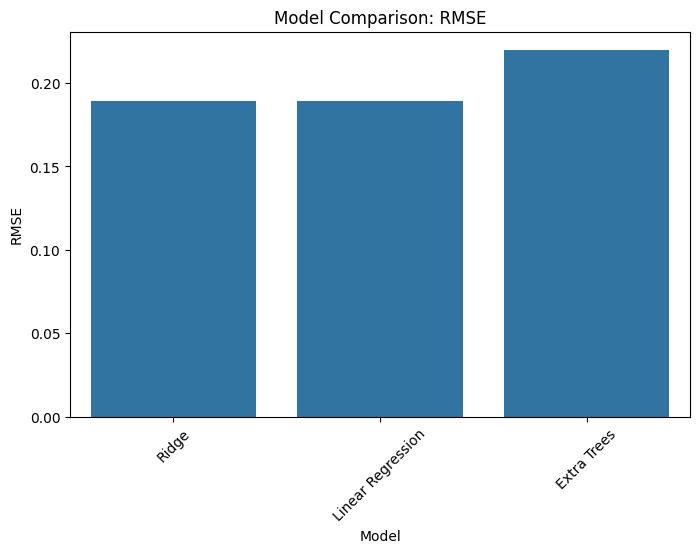

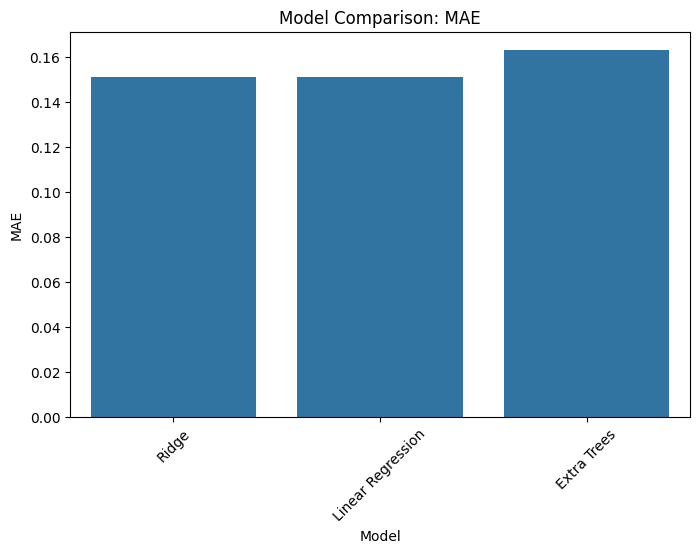

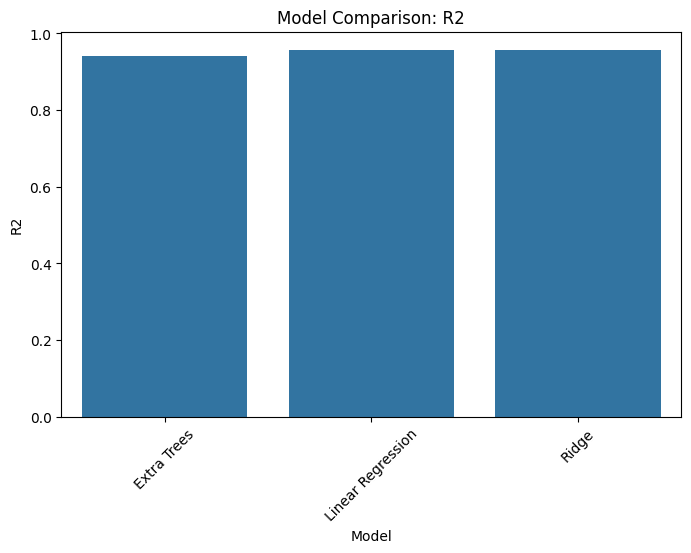


Предсказания vs Реальные значения для Ridge:


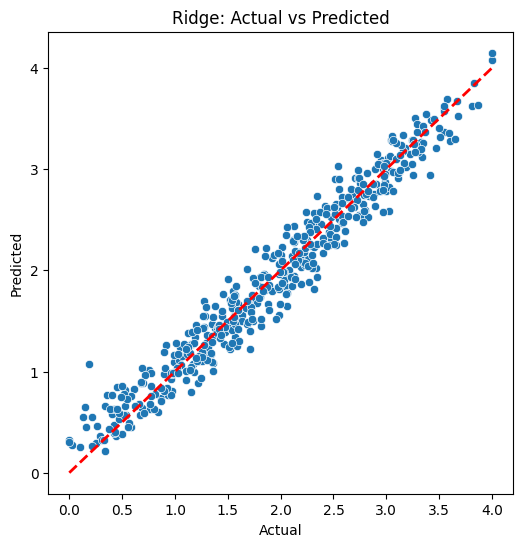


Предсказания vs Реальные значения для Linear Regression:


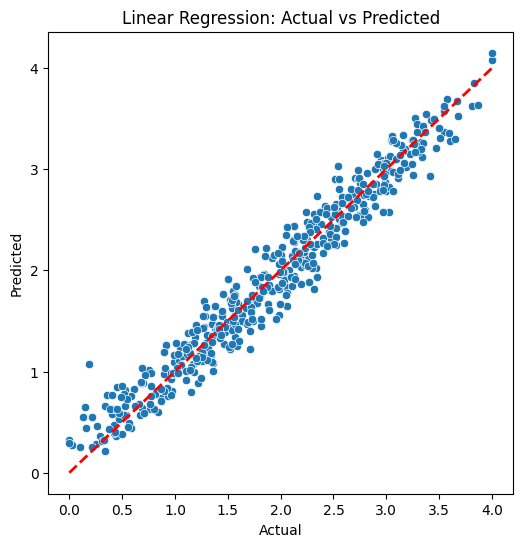


Предсказания vs Реальные значения для Extra Trees:


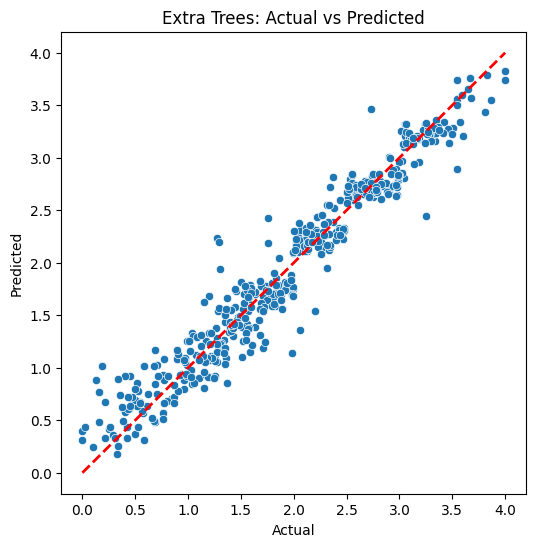

In [9]:
## Сравнение топ‑3 после настройки

from visualization import plot_model_comparison, plot_prediction_vs_real

print("Сравнение топ-3 моделей после настройки гиперпараметров:")
plot_model_comparison(tuned_results_df, metric="RMSE")
plot_model_comparison(tuned_results_df, metric="MAE")
plot_model_comparison(tuned_results_df, metric="R2")

for name, model in best_models:
    print(f"\nПредсказания vs Реальные значения для {name}:")
    y_pred = model.predict(X_test)
    plot_prediction_vs_real(y_test, y_pred, model_name=name)

Hexbin и Residual plot для топ‑3 моделей:


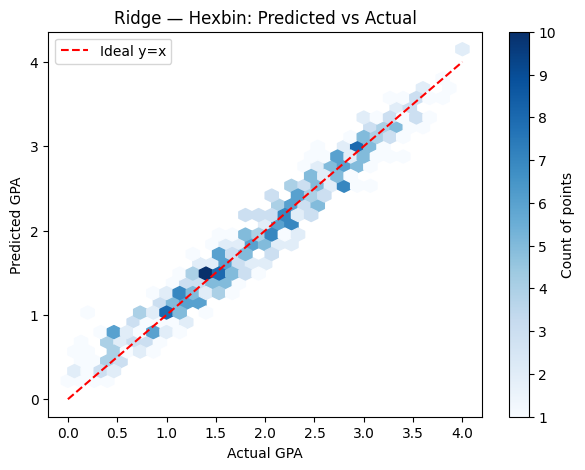

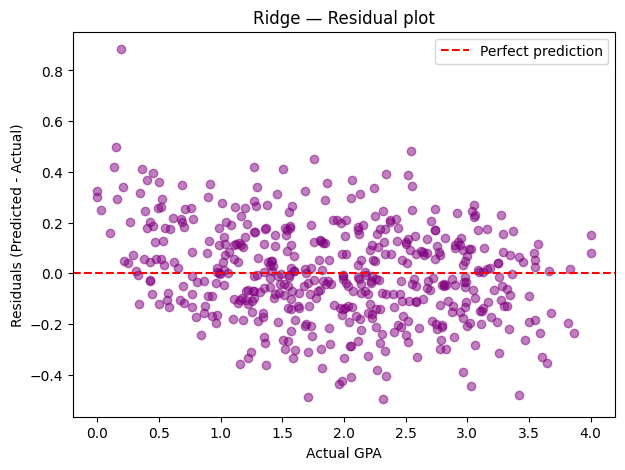

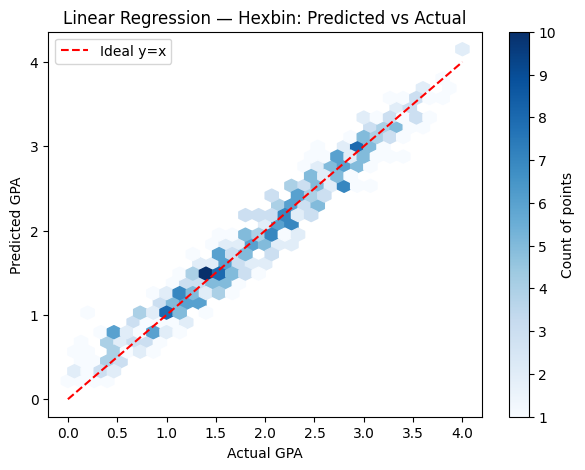

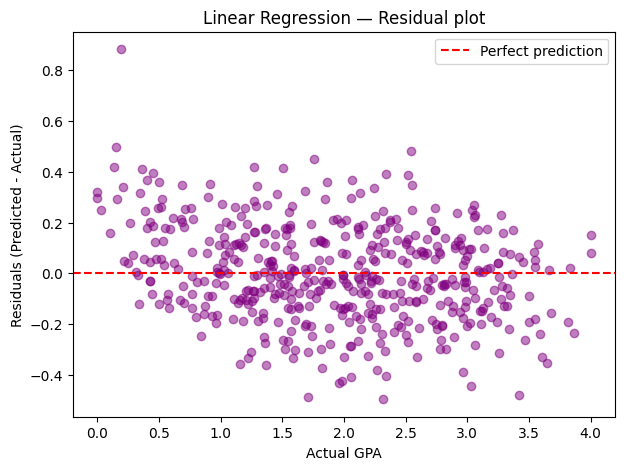

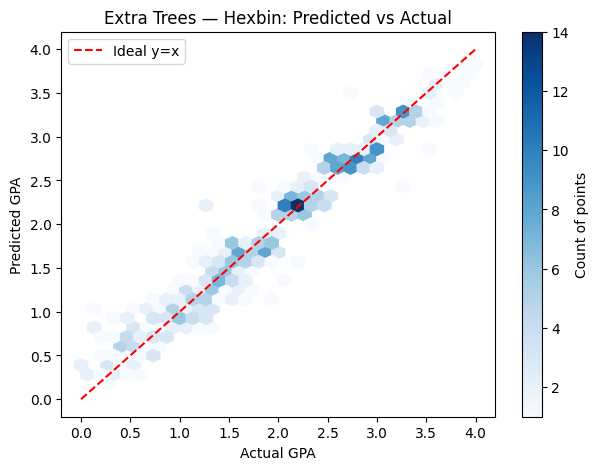

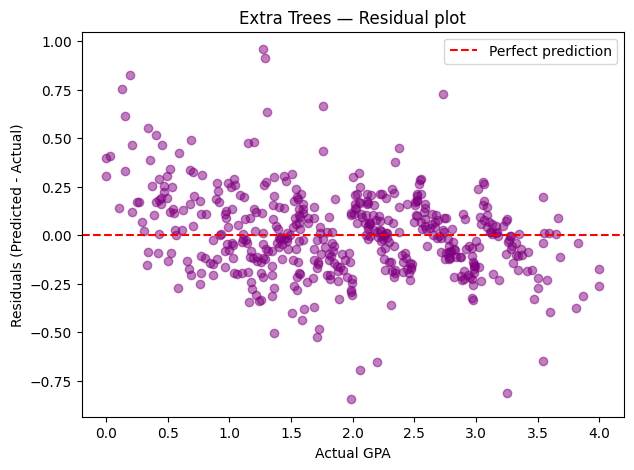

In [13]:
## Hexbin и Residual plot для топ‑3 моделей

import matplotlib.pyplot as plt
import numpy as np

print("Hexbin и Residual plot для топ‑3 моделей:")

for name, model in best_models:
    y_pred = model.predict(X_test)
    residuals = y_pred - y_test

    # 1️⃣ Hexbin plot
    plt.figure(figsize=(7,5))
    plt.hexbin(y_test, y_pred, gridsize=30, cmap='Blues', mincnt=1)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Ideal y=x')
    plt.xlabel("Actual GPA")
    plt.ylabel("Predicted GPA")
    plt.title(f"{name} — Hexbin: Predicted vs Actual")
    plt.colorbar(label='Count of points')
    plt.legend()
    plt.show()

    # 2️⃣ Residual plot
    plt.figure(figsize=(7,5))
    plt.scatter(y_test, residuals, alpha=0.5, color='purple')
    plt.axhline(0, color='red', linestyle='--', label='Perfect prediction')
    plt.xlabel("Actual GPA")
    plt.ylabel("Residuals (Predicted - Actual)")
    plt.title(f"{name} — Residual plot")
    plt.legend()
    plt.show()

# Что делает блок:

**Hexbin plot**

Цвет показывает, где наибольшая плотность точек

Красная линия y=x показывает идеальное совпадение

Очень удобно для больших наборов данных

**Residual plot**

Y = ошибки (predicted − actual)

X = реальные значения GPA

Если точки разбросаны вокруг 0 → модель предсказывает хорошо

Вертикальные смещения и выбросы легко увидеть

Hexbin plot: Сравнение топ-3 моделей — Predicted vs Actual GPA


/tmp/ipykernel_13911/1051585750.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.hexbin(y_test, y_pred, gridsize=30, cmap=plt.cm.get_cmap('Reds', 30) if i==0 else plt.cm.get_cmap('Greens', 30) if i==1 else plt.cm.get_cmap('Blues', 30), alpha=0.5, mincnt=1, label=name)
/tmp/ipykernel_13911/1051585750.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  plt.hexbin(y_test, y_pred, gridsize=30, cmap=plt.cm.get_cmap('Reds', 30) if i==0 else plt.cm.get_cmap('Greens', 30) if i==1 else plt.cm.get_cmap('Blues', 30), alpha=0.5, mincnt=1, label=name)
/tmp/ipykernel_13911/1051585750.py:12: MatplotlibDeprecationWarning: The get_cmap function

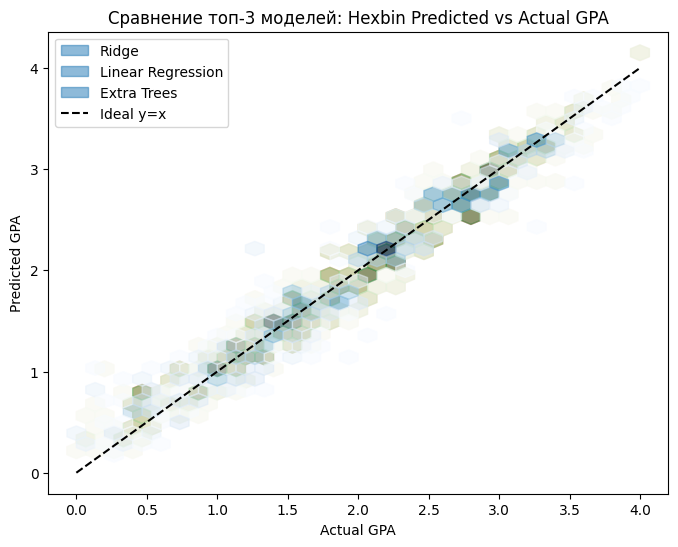

In [14]:
## Сравнение точность предсказаний всех топ‑3 моделей на одном графике

import matplotlib.pyplot as plt

print("Hexbin plot: Сравнение топ-3 моделей — Predicted vs Actual GPA")

plt.figure(figsize=(8,6))

colors = ['red', 'green', 'blue']  # цвета для моделей
for i, (name, model) in enumerate(best_models):
    y_pred = model.predict(X_test)
    plt.hexbin(y_test, y_pred, gridsize=30, cmap=plt.cm.get_cmap('Reds', 30) if i==0 else plt.cm.get_cmap('Greens', 30) if i==1 else plt.cm.get_cmap('Blues', 30), alpha=0.5, mincnt=1, label=name)

# Линия идеального совпадения
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', label='Ideal y=x')

plt.xlabel("Actual GPA")
plt.ylabel("Predicted GPA")
plt.title("Сравнение топ-3 моделей: Hexbin Predicted vs Actual GPA")
plt.legend()
plt.show()

# Что делает блок:

**Цель:**

Сравнить точность предсказаний всех топ‑3 моделей на одном графике.

**Что делает:**

Hexbin plot показывает плотность точек (Actual vs Predicted GPA) для каждой модели отдельным цветом.

Красная пунктирная линия y=x — идеальное совпадение предсказаний с реальными значениями.

**Почему удобно:**

Большое количество наблюдений (>1000) не «сливается» в scatter overlay.

Видно, где модели точные (плотность ближе к линии) и где есть ошибки.

Цвета помогают различать модели и сравнивать их качество.

**Как читать:**

Чем ближе плотность к линии y=x → точнее модель.

Плотность ниже линии → модель недооценивает GPA.

Плотность выше линии → модель переоценивает GPA.